# M5 Forecasting - Exploratory Data Analysis

Exploratory analysis of demand patterns, seasonality, event effects, pricing, and inventory risk in the M5 dataset.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import re
import gc

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["LOKY_MAX_CPU_COUNT"] = "4"  

warnings.filterwarnings("ignore", message="Could not find the number of physical cores*")
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak on Windows with MKL*")

In [2]:
from IPython.display import HTML
HTML("""
<div style="background:linear-gradient(135deg,#1a237e 0%,#6a1b9a 100%);
            padding:28px 24px;border-radius:14px;margin:6px 0;
            box-shadow:0 4px 20px rgba(0,0,0,.4)">
  <h1 style="color:#fff;font-size:2.2em;margin:0 0 6px;
             font-family:system-ui,sans-serif;letter-spacing:-.5px">
    M5 Forecasting &mdash; Exploratory Data Analysis
  </h1>
  <p style="color:rgba(255,255,255,.85);font-size:1.05em;margin:0;
            font-family:system-ui,sans-serif">
    Demand Patterns &bull; Seasonality &bull; Event Effects &bull;
    Pricing &bull; Inventory Risk
  </p>
</div>
""")

#### Introduction

##### The M5 Forecasting dataset is a large-scale retail sales dataset that contains daily sales records for thousands of products across multiple stores and states over several years. The primary goal is to understand demand patterns and build accurate forecasting models that can predict future sales at different aggregation levels (item, store, and state). Before developing forecasting models, performing Exploratory Data Analysis (EDA) is essential to uncover seasonality, trends, promotional effects, price sensitivity, and demand volatility, ensuring that modeling decisions are data-driven and aligned with real business behavior.

#### Data Overview and Pre-processing

In [3]:
calendar = pd.read_csv("data/calendar.csv")
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [ ]:
calendar = calendar.where(pd.notna(calendar), None)
calendar.drop(columns=["wday"], inplace=True)

calendar.info()

In [ ]:
# downcast dtypes
int_cols = ['wm_yr_wk', 'month', 'year', 'snap_CA', 'snap_TX', 'snap_WI']
calendar[int_cols] = calendar[int_cols].apply(pd.to_numeric, downcast='unsigned')

cat_cols = ['weekday', 'event_name_1', 'event_name_2', 'event_type_1', 'event_type_2']
calendar[cat_cols] = calendar[cat_cols].astype('category')

calendar['date'] = pd.to_datetime(calendar['date'])

calendar.info()

In [ ]:
cols = ["event_name_1", "event_type_1", 
        "event_name_2", "event_type_2"]

for col in cols:
    calendar[col] = calendar[col].cat.add_categories("None")
    calendar[col] = calendar[col].fillna("None")

calendar.head()

In [ ]:
calendar.to_parquet('calendar.parquet', index=False)

In [8]:
sales = pd.read_csv("data/sales_train_validation.csv")
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [ ]:
sales.drop(columns=["id"], inplace=True)

In [10]:
sales = sales.melt(
    id_vars=['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    var_name='d',
    value_name='sales'
)

In [ ]:
sales.to_parquet('sales.parquet', index=False)

In [13]:
CHUNK_SIZE = 500_000
chunks = []

for start in range(0, len(sales), CHUNK_SIZE):
    chunk = sales.iloc[start:start + CHUNK_SIZE]
    
    merged = chunk.merge(calendar, on='d', how='left')
    merged = merged.drop(columns='d')
    
    chunks.append(merged)
    
    del chunk, merged
    gc.collect()

df = pd.concat(chunks, ignore_index=True)
del chunks, sales, calendar
gc.collect()

out_path = "merged_df.parquet"
df.to_parquet(out_path, index=False)

print("Saved:", out_path, "rows:", len(df), "cols:", df.shape[1])

Saved: merged_df.parquet rows: 58327370 cols: 18


In [14]:
df = pd.read_parquet("merged_df.parquet")
sell_prices = pd.read_csv("data/sell_prices.csv")
sell_prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [15]:
df.head()

,item_id,dept_id,cat_id,store_id,state_id,sales,date,wm_yr_wk,weekday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,2011-01-29,11101,Saturday,1,2011,None,None,None,None,0,0,0
1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,2011-01-29,11101,Saturday,1,2011,None,None,None,None,0,0,0
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,2011-01-29,11101,Saturday,1,2011,None,None,None,None,0,0,0
3,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,2011-01-29,11101,Saturday,1,2011,None,None,None,None,0,0,0
4,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,2011-01-29,11101,Saturday,1,2011,None,None,None,None,0,0,0


In [ ]:
# merge snap cols
df["snap"] = 0

df.loc[df["state_id"].eq("CA"), "snap"] = df.loc[df["state_id"].eq("CA"), "snap_CA"].values
df.loc[df["state_id"].eq("TX"), "snap"] = df.loc[df["state_id"].eq("TX"), "snap_TX"].values
df.loc[df["state_id"].eq("WI"), "snap"] = df.loc[df["state_id"].eq("WI"), "snap_WI"].values

df["snap"] = df["snap"].astype("int8")
df.drop(columns=["snap_CA", "snap_TX", "snap_WI"], inplace=True)

df.head()

In [ ]:
# align dtypes
df["store_id"] = df["store_id"].astype("string")
df["item_id"]  = df["item_id"].astype("string")
df["wm_yr_wk"] = df["wm_yr_wk"].astype("int32")

sell_prices["store_id"] = sell_prices["store_id"].astype("string")
sell_prices["item_id"]  = sell_prices["item_id"].astype("string")
sell_prices["wm_yr_wk"] = sell_prices["wm_yr_wk"].astype("int32")
sell_prices["sell_price"] = sell_prices["sell_price"].astype("float32")

CHUNK_SIZE = 500_000
out_chunks = []

sell_prices_small = sell_prices[["store_id", "item_id", "wm_yr_wk", "sell_price"]]

for start in range(0, len(df), CHUNK_SIZE):
    chunk = df.iloc[start:start + CHUNK_SIZE]

    merged = chunk.merge(
        sell_prices_small,
        on=["store_id", "item_id", "wm_yr_wk"],
        how="left",
        copy=False
    )

    out_chunks.append(merged)

    del chunk, merged
    gc.collect()

df2 = pd.concat(out_chunks, ignore_index=True)

del out_chunks
gc.collect()

out_path = "df2_merged.parquet"
df2.to_parquet(out_path, index=False, compression="snappy")

print("Saved:", out_path, "| shape:", df2.shape)
gc.collect()

In [ ]:
df2["sell_price"] = df2["sell_price"].astype(object)
df2.loc[df2["sell_price"].isna(), "sell_price"] = None

df2.head()

In [ ]:
df2.drop(columns=["wm_yr_wk"], inplace=True)

#### Exploratory Data Analysis

In [ ]:
print("Shape:", df2.shape)
display(df2.head(3))

In [ ]:
def quick_profile(df, max_unique_check=50):
    out = []
    n = len(df)
    for c in df.columns:
        s = df[c]
        miss = int(s.isna().sum())
        miss_pct = (miss / n) * 100 if n else 0
        dtype = str(s.dtype)

        if dtype in ("object", "string", "category"):
            sample = s.dropna()
            if len(sample) > 1_000_000:
                sample = sample.sample(1_000_000, random_state=42)
            nunique = int(sample.nunique())
            nunique_note = "approx(sample)" if len(s.dropna()) > len(sample) else "exact"
        else:
            nunique = int(s.nunique(dropna=True))
            nunique_note = "exact"

        out.append([c, dtype, miss, round(miss_pct, 3), nunique, nunique_note])

    return pd.DataFrame(out, columns=["col","dtype","missing","missing_%","n_unique","unique_note"]).sort_values("missing_%", ascending=False)

profile = quick_profile(df2)
display(profile)

In [ ]:
num_cols = df2.select_dtypes(include=[np.number]).columns.tolist()
display(df2[num_cols].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]).T)

In [ ]:
if "date" in df2.columns:
    print("Date min:", df2["date"].min(), "Date max:", df2["date"].max())

In [ ]:
if "sales" in df2.columns:
    zero_rate = (df2["sales"].fillna(0) == 0).mean() * 100
    print(f"Sales=0 rate: {zero_rate:.2f}%")

In [ ]:
for c in ["weekday", "event_type_1", "event_name_1", "event_type_2", "event_name_2"]:
    if c in df2.columns:
        print(f"\n=== Value counts: {c} ===")
        vc = df2[c].value_counts(dropna=False)
        display(vc.head(30))

### Global Demand Overview

In [26]:
import matplotlib.pyplot as plt
import os

In [ ]:
import matplotlib.cm as cm

PALETTE = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52",
    "#8172B2", "#937860", "#DA8BC3", "#64B5CD",
]

plt.rcParams.update({
    "figure.figsize":    (11, 5),
    "figure.dpi":        110,
    "figure.facecolor":  "#FAFAFA",
    "axes.facecolor":    "#FFFFFF",
    "axes.grid":         True,
    "grid.color":        "#E0E0E0",
    "grid.linewidth":    0.7,
    "grid.linestyle":    "--",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.prop_cycle":   plt.cycler(color=PALETTE),
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.framealpha": 0.9,
    "patch.edgecolor":   "none",
})

#### 📈 Total Sales Over Time

In [ ]:
# rolling averages
daily      = df2.groupby("date", observed=True)["sales"].sum().sort_index()
rolling_7  = daily.rolling(7).mean()
rolling_30 = daily.rolling(30).mean()

fig, ax = plt.subplots()
ax.fill_between(daily.index, daily.values, alpha=0.12, color=PALETTE[0])
ax.plot(daily.index,      daily.values,      alpha=0.35, color=PALETTE[0], lw=0.8, label="Daily")
ax.plot(rolling_7.index,  rolling_7.values,  color=PALETTE[1], lw=1.8, label="7-day MA")
ax.plot(rolling_30.index, rolling_30.values, color=PALETTE[2], lw=2.5, label="30-day MA")
ax.set_title("Sales Trend with Rolling Averages")
ax.set_xlabel("Date"); ax.set_ylabel("Total Sales")
ax.legend()
plt.tight_layout(); plt.show()

##### Sales show a clear upward trend from 2011 to 2016, with strong short-term fluctuations that are smoothed by the 7-day and 30-day moving averages. The 7-day line captures weekly seasonality, while the 30-day line highlights the longer-term growth pattern. A few sharp drops to near-zero appear as outliers and likely correspond to unusual days (e.g., store closures or data gaps) worth investigating separately.

In [ ]:
yearly_total = df2.groupby("year", observed=True)["sales"].sum().sort_index()
colors_yr    = cm.Blues(np.linspace(0.35, 0.85, len(yearly_total)))

fig, ax = plt.subplots()
bars = ax.bar(yearly_total.index.astype(str), yearly_total.values, color=colors_yr, width=0.55)
for bar, val in zip(bars, yearly_total.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + yearly_total.max() * 0.01,
            f"{val / 1e6:.1f}M", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Total Sales by Year (Trend)")
ax.set_xlabel("Year"); ax.set_ylabel("Total Sales")
plt.tight_layout(); plt.show()
display(yearly_total)

##### Total sales increase strongly from 2011 (8.86M) to 2013 (13.14M), remain relatively stable in 2014 (13.09M), and peak in 2015 (13.80M), indicating steady growth over most of the period. The sharp drop in 2016 (4.75M) is expected because the dataset only covers part of 2016 (not a full year), so it shouldn’t be interpreted as a true decline.

#### 📅 Weekly Seasonality

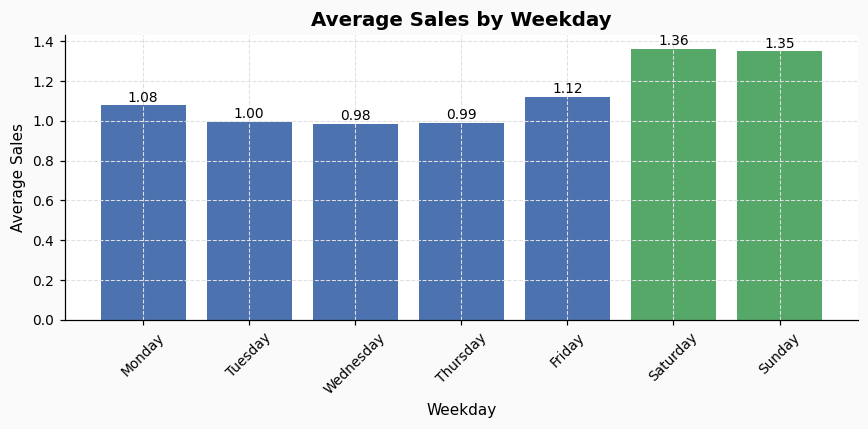

In [30]:
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekday_sales = (
    df2.groupby("weekday", observed=True)["sales"]
       .mean()
       .reindex(weekday_order)
)
wd_colors = [PALETTE[0]] * 5 + [PALETTE[2], PALETTE[2]]   # highlight weekends

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(weekday_order, weekday_sales.values, color=wd_colors)
for bar, val in zip(bars, weekday_sales.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_title("Average Sales by Weekday")
ax.set_xlabel("Weekday"); ax.set_ylabel("Average Sales")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

##### Average sales show a clear weekly seasonality pattern. Sales are relatively steady from Tuesday to Thursday (around 1.0), increase on Friday, and peak on the weekend, with Saturday and Sunday having the highest average sales (1.35). This suggests stronger customer demand during weekends, making weekday/is_weekend important calendar features for forecasting.

#### 📆 Monthly Seasonality

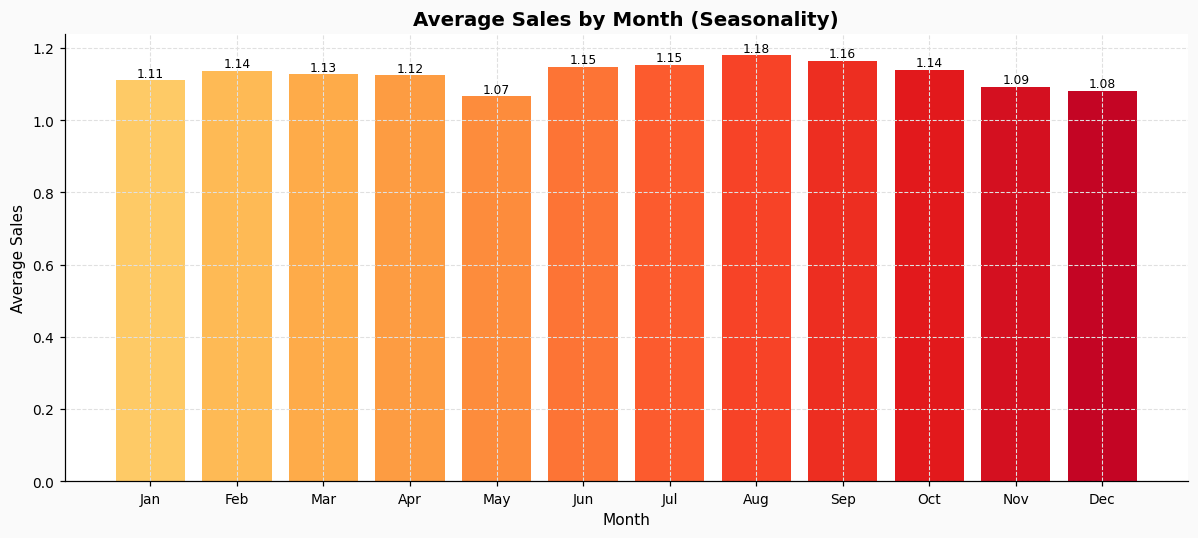

month
1     1.109621
2     1.136262
3     1.126266
4     1.123604
5     1.066050
6     1.147964
7     1.151932
8     1.178965
9     1.163636
10    1.138520
11    1.091861
12    1.081681
Name: sales, dtype: float64

In [31]:
monthly_avg  = df2.groupby("month", observed=True)["sales"].mean().sort_index()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
colors_mo    = cm.YlOrRd(np.linspace(0.30, 0.85, 12))

fig, ax = plt.subplots()
bars = ax.bar(month_labels, monthly_avg.values, color=colors_mo)
for bar, val in zip(bars, monthly_avg.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{val:.2f}", ha="center", va="bottom", fontsize=8)
ax.set_title("Average Sales by Month (Seasonality)")
ax.set_xlabel("Month"); ax.set_ylabel("Average Sales")
plt.tight_layout(); plt.show()
display(monthly_avg)

##### Average sales show a mild but clear monthly seasonality. Demand is lowest around May (1.07), then rises through summer and peaks in August–September (1.18–1.16), before easing again toward the end of the year (Nov–Dec 1.09–1.08). Overall variation is not huge, but the consistent summer uplift suggests month is a useful seasonal feature for forecasting.

In [ ]:
monthly = df2.groupby(["year","month"], observed=True)["sales"].sum().reset_index()
pivot   = monthly.pivot(index="month", columns="year", values="sales")
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots()
for year in pivot.columns:
    ax.plot(month_labels, pivot[year], label=str(year), lw=2, marker="o", markersize=4)
ax.set_title("Monthly Sales by Year")
ax.set_xlabel("Month"); ax.set_ylabel("Total Sales")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Year")
plt.tight_layout(); plt.show()

##### The month-by-month comparison across years shows a consistent seasonal pattern, with sales generally rising mid-year and peaking around late summer (July–September) in most years. Overall demand trends upward from 2011 through 2015, indicating steady growth, while 2016 appears incomplete and should not be directly compared as a full year. The repeating seasonal shape across years confirms strong and stable monthly seasonality in the dataset

### Promotional & Event Impact

#### SNAP lift by state

In [ ]:
# SNAP lift by state
snap_state = (
    df2.groupby(["state_id", "snap"], observed=True)["sales"]
      .mean()
      .unstack()
)
snap_state["lift_%"] = (snap_state[1] - snap_state[0]) / snap_state[0] * 100

states = snap_state.index.astype(str).tolist()
x, w  = range(len(states)), 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([i - w/2 for i in x], snap_state[0].values, width=w, color=PALETTE[0], alpha=0.85, label="SNAP=0")
ax.bar([i + w/2 for i in x], snap_state[1].values, width=w, color=PALETTE[2], alpha=0.85, label="SNAP=1")
ax.set_xticks(list(x)); ax.set_xticklabels(states)
ax.set_title("SNAP Lift by State")
ax.set_xlabel("State"); ax.set_ylabel("Average Sales")
ax.legend()

for i, (state, row) in enumerate(snap_state.iterrows()):
    ax.text(i, max(row[0], row[1]) + 0.02,
            f"+{row['lift_%']:.1f}%", ha="center",
            fontsize=9, fontweight="bold", color=PALETTE[2])
plt.tight_layout(); plt.show()
display(snap_state)

##### SNAP days consistently increase average sales across all states, confirming a clear promotional lift effect. The impact is strongest in Wisconsin (+21.8%), followed by Texas (+11.5%), and more moderate in California (+8.0%). This indicates SNAP benefits drive measurable demand uplift, particularly in WI, making snap a highly valuable forecasting feature and a key driver of short-term demand spikes.

#### Event Distribution and Impact Ranking

In [ ]:
s = df2["event_type_1"].astype("string")
event_type_counts = s[(s != "None") & (s.notna())].value_counts()

colors_pie = PALETTE[:len(event_type_counts)]
explode    = [0.04] * len(event_type_counts)

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    event_type_counts.values,
    labels      = event_type_counts.index,
    autopct     = "%1.1f%%",
    startangle  = 90,
    colors      = colors_pie,
    explode     = explode,
    shadow      = True,
    pctdistance = 0.75,
    wedgeprops  = dict(linewidth=1.5, edgecolor="white"),
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
    at.set_color("white")
ax.set_title("Distribution of Event Types", pad=16)
plt.tight_layout(); plt.show()

##### Religious and National events dominate the event distribution, together accounting for roughly two-thirds of all events (≈34% each), while Cultural events represent about 23% and Sporting events around 10%. This indicates that most calendar-driven demand shifts are tied to major religious and national occasions, suggesting these categories may have broader and more consistent impact compared to sporting events.

In [ ]:
def clean_event_name(s: str) -> str:
    s = re.sub(r"(?<!^)(?=[A-Z])", " ", s)
    s = s.replace("N B A", "NBA").replace("U S A", "USA")
    s = s.replace("Al", "al")
    return s.strip()

event_effect = (
    df2[df2["event_name_1"].astype("string") != "None"]
    .groupby("event_name_1", observed=True)["sales"]
    .mean()
    .sort_values(ascending=False)
)

top10      = event_effect.head(10)
labels     = [clean_event_name(x) for x in top10.index.astype(str)]
bar_colors = cm.RdYlGn(np.linspace(0.4, 0.9, len(top10)))[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(labels[::-1], top10.values[::-1], color=bar_colors)
ax.set_title("Top 10 High-Impact Events")
ax.set_xlabel("Average Sales")
plt.tight_layout(); plt.show()

##### The top-performing events are largely major national and religious holidays, with Labor Day and Super Bowl showing the highest average sales impact, followed closely by Easter and Orthodox Easter. This suggests that large-scale holidays and culturally significant events drive noticeable demand spikes, making event-level features important for capturing short-term sales surges in forecasting models.

### Price Behavior & Elasticity

In [ ]:
dept_price = df2.groupby("dept_id", observed=True)["sell_price"].mean().sort_values(ascending=False)
display(dept_price)

# sample correlation
sample = df2[["sales","sell_price"]].dropna()
if len(sample) > 2_000_000:
    sample = sample.sample(2_000_000, random_state=42)

print("Sample correlation:", sample["sales"].corr(sample["sell_price"]))

##### Average price differs a lot by department. HOBBIES_1 items are the most expensive on average (6.21), while HOBBIES_2 and FOODS_3 are the cheapest (2.69 and 2.84). This tells us departments sit in different price tiers. The correlation between price and sales is -0.15, which is a weak negative relationship. That means higher prices are slightly associated with lower sales, but the effect is not strong overall—so demand isn’t purely driven by price and likely depends on other factors (seasonality, promotions, events, item type, etc.).

In [ ]:
df2["sell_price"] = pd.to_numeric(df2["sell_price"], errors="coerce")

dfp = df2[["sell_price", "sales"]].dropna()
if len(dfp) > 3_000_000:
    dfp = dfp.sample(3_000_000, random_state=42)

dfp["price_q"] = pd.qcut(dfp["sell_price"], q=20, duplicates="drop")
q_effect = dfp.groupby("price_q", observed=True)["sales"].mean()

xs = range(len(q_effect))
fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(xs, q_effect.values, alpha=0.20, color=PALETTE[3])
ax.plot(xs, q_effect.values, marker="o", markersize=6, color=PALETTE[3], lw=2)
ax.set_title("Price Quantile Effect: Average Sales vs Price Level")
ax.set_xlabel("Price Quantile (low → high)"); ax.set_ylabel("Average Sales")
plt.tight_layout(); plt.show()

##### The chart clearly shows that lower-priced items sell significantly more than higher-priced ones. Average sales are highest in the cheapest price groups and steadily decline as price increases, indicating strong price sensitivity. In simple terms, cheaper products drive higher demand, while more expensive items sell less frequently.

### Demand Structure & Risk

#### Inventory Risk 

In [ ]:
item_stats = df2.groupby("item_id", observed=True)["sales"].agg(["mean","std","sum"])

item_stats["cv"] = item_stats["std"] / (item_stats["mean"] + 1e-6)
item_stats["log_total_sales"] = np.log1p(item_stats["sum"])

display(item_stats.head())

##### These item-level metrics show strong variation in demand behavior across products. Some items have low average sales but high volatility (high CV), meaning demand is irregular and harder to forecast, while others have higher mean sales and lower CV, indicating more stable demand. The log_total_sales helps compare overall volume across items, highlighting which products are major contributors versus low-volume/intermittent sellers.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    item_stats["log_total_sales"], item_stats["cv"],
    c=item_stats["cv"], cmap="RdYlGn_r", alpha=0.5, s=18,
)
plt.colorbar(sc, ax=ax, label="Volatility (CV)")
ax.axhline(item_stats["cv"].median(), linestyle="--", color=PALETTE[3], lw=1.5, alpha=0.8)
ax.set_title("Inventory Risk Map")
ax.set_xlabel("Log Total Sales (Volume)"); ax.set_ylabel("Demand Volatility (CV)")
plt.tight_layout(); plt.show()

##### The Inventory Risk Map shows a clear inverse relationship between sales volume and demand volatility. High-volume items (right side) tend to have lower CV values, meaning they are more stable and predictable, while low-volume items (left side) exhibit much higher volatility and therefore greater inventory risk. This suggests that slow-moving products are more unpredictable and may require cautious stocking strategies, whereas high-volume items are safer and easier to plan inventory for.

#### Revenue Concentration

In [ ]:
item_revenue = df2.groupby("item_id", observed=True)["sales"].sum()
item_revenue = item_revenue.sort_values(ascending=False)
cum_pct = item_revenue.cumsum() / item_revenue.sum() * 100
x = np.arange(1, len(item_revenue) + 1)

bar_c = cm.Blues(np.linspace(0.40, 0.85, 200))[::-1]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(x[:200], item_revenue.values[:200], color=bar_c)
ax1.set_xlabel("Item Rank (Top items on left)")
ax1.set_ylabel("Revenue", color=PALETTE[0])

ax2 = ax1.twinx()
ax2.plot(x, cum_pct.values, color=PALETTE[3], lw=2)
ax2.axhline(80, linestyle="--", color=PALETTE[3], alpha=0.55, lw=1.2)
ax2.set_ylabel("Cumulative % of Revenue", color=PALETTE[3])
ax2.set_ylim(0, 105)

ax1.set_title("Revenue Concentration (Pareto Analysis)")
plt.tight_layout(); plt.show()

##### The Pareto chart shows strong revenue concentration: a relatively small number of top-ranked items generate the majority of total revenue. The cumulative curve rises steeply at the beginning, indicating that roughly the top 20–30% of items contribute around 80% of total sales. This confirms a classic 80/20 pattern, meaning a focused inventory and forecasting strategy on high-impact items can drive most of the business value. 

#### Sparsity distribution

In [ ]:
zero_rate = (df2["sales"] == 0).mean() * 100
print(f"Overall zero-sales rate: {zero_rate:.2f}%")

In [ ]:
item_zero_rate = df2.groupby("item_id", observed=True)["sales"].apply(lambda x: (x == 0).mean())

fig, ax = plt.subplots(figsize=(8, 4))
n, bins, patches = ax.hist(item_zero_rate, bins=50, edgecolor="white", linewidth=0.5)
fracs = (n - n.min()) / (n.max() - n.min() + 1e-9)
for frac, patch in zip(fracs, patches):
    patch.set_facecolor(cm.Purples(0.30 + 0.55 * frac))

ax.set_title("Sparsity Distribution: Zero-Sales Rate per Item")
ax.set_xlabel("Zero-Sales Rate (per item)"); ax.set_ylabel("Number of Items")
plt.tight_layout(); plt.show()
display(item_zero_rate.describe())

##### The sparsity distribution shows that most items have a very high zero-sales rate, with an average of about 68% and a median around 73%. This means that for most products, sales occur on fewer than one-third of the days, indicating highly intermittent demand. Such high sparsity makes forecasting more challenging and suggests that specialized techniques for intermittent demand may be necessary.

In [ ]:
thresholds = [0.5, 0.7, 0.8, 0.9, 0.95]
counts     = [(item_zero_rate >= t).sum() for t in thresholds]
colors_thr = cm.Reds(np.linspace(0.30, 0.85, len(thresholds)))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([f">={int(t*100)}%" for t in thresholds], counts, color=colors_thr)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts) * 0.01,
            str(int(cnt)), ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Items with High Sparsity (Zero-Sales Rate Thresholds)")
ax.set_xlabel("Zero-rate threshold"); ax.set_ylabel("Number of Items")
plt.tight_layout(); plt.show()

for t, c in zip(thresholds, counts):
    print(f"Items with zero-rate >= {t:.2f}: {int(c)}")

##### The majority of items exhibit high sparsity: about 2,451 items (≈80%) have zero sales on at least half of the days, and 1,633 items have zero sales on 70% or more of days. Even more extreme, 401 items have zero sales on over 90% of days. This confirms that a large portion of the catalog consists of slow-moving or intermittent products, which significantly increases forecasting complexity and inventory risk.

In [ ]:
dept_zero = (
    df2.groupby(["dept_id","item_id"], observed=True)["sales"]
    .apply(lambda x: (x == 0).mean())
    .reset_index(name="zero_rate")
)

depts = sorted(dept_zero["dept_id"].astype(str).unique())
data  = [dept_zero.loc[dept_zero["dept_id"].astype(str) == d, "zero_rate"].values for d in depts]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(
    data, labels=depts, patch_artist=True,
    showfliers=False,
    medianprops=dict(color="black", linewidth=2),
)
for patch, color in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_title("Sparsity by Department (Zero-Rate per Item)")
ax.set_xlabel("Department"); ax.set_ylabel("Zero-Sales Rate")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

##### Sparsity varies noticeably across departments. HOBBIES_2 and HOUSEHOLD_2 show the highest median zero-sales rates, meaning most items in these departments sell infrequently and are highly intermittent. In contrast, FOODS departments generally have lower sparsity, indicating more regular and consistent demand. This suggests forecasting and inventory strategies should differ by department, with hobby and certain household items requiring more cautious planning due to higher intermittency.

#### Clustering segmentation

In [ ]:
# item-level features
item_stats = df2.groupby("item_id", observed=True)["sales"].agg(["mean", "std", "sum"])
item_stats["cv"] = item_stats["std"] / (item_stats["mean"] + 1e-6)
item_stats["zero_rate"] = df2.groupby("item_id", observed=True)["sales"].apply(lambda x: (x == 0).mean())

features = item_stats[["mean", "cv", "zero_rate"]].dropna()
features.head()

##### These item-level features summarize each product’s demand behavior: mean captures average daily demand, CV (std/mean) measures how volatile sales are relative to the average, and zero_rate shows how often the item has zero sales (intermittent demand). Together, they help segment items into groups like stable fast-movers (higher mean, lower CV/zero_rate) versus slow-moving and irregular items (low mean, high CV and high zero_rate), which is useful for forecasting and inventory strategy.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaled = StandardScaler().fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled)

features = features.copy()
features["cluster"] = clusters

display(features["cluster"].value_counts().sort_index())
display(features.groupby("cluster")[["mean","cv","zero_rate"]].mean())

##### The clustering shows four clear demand groups. One small group IS high-selling and stable products — your key revenue drivers. Another group has medium sales and moderate stability. Most items fall into low-selling and intermittent groups, with one cluster showing very slow-moving and highly irregular demand, making them the hardest to forecast and highest inventory risk.

In [ ]:
centers = features.groupby("cluster")[["mean", "cv"]].mean()

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    features["mean"], features["cv"],
    c=features["cluster"], cmap="Set2",
    alpha=0.7, s=20, zorder=2,
)
plt.colorbar(sc, ax=ax, label="Cluster", ticks=[0, 1, 2, 3])
ax.scatter(centers["mean"], centers["cv"],
           c="black", s=60, marker="D", edgecolors="white", linewidths=1.5, zorder=10)
for k in centers.index:
    ax.text(centers.loc[k, "mean"], centers.loc[k, "cv"],
            f" C{k}", fontsize=10, color="black", va="center", ha="left", zorder=11,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5))
ax.set_title("Clustering Segmentation: Mean Sales vs Volatility (CV)")
ax.set_xlabel("Mean Sales"); ax.set_ylabel("Volatility (CV)")
plt.tight_layout(); plt.show()

##### Cluster 2 – Mostly **FOODS**: fast-moving, high-demand staple items.

##### Cluster 3 – FOODS + some HOUSEHOLD: moderate demand, fairly stable products.

##### Cluster 0 – Mostly HOUSEHOLD + some HOBBIES: low sales, more irregular items.

##### Cluster 1 – Mostly HOBBIES: very slow-moving, highly intermittent products.


### Seasonal Decomposition

In [ ]:
# aggregate daily
daily = df2.groupby("date", observed=True)["sales"].sum().sort_index()

from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(daily, model="additive", period=7)

fig = decomp.plot()
fig.set_size_inches(12,8)
plt.show()

##### Trend: Sales steadily increase over the years, confirming long-term growth.

##### Seasonality: There is a strong and consistent repeating weekly pattern, showing clear regular demand cycles.

##### Residuals: Most fluctuations are small, but there are occasional sharp spikes and drops, likely due to special events or holidays.

### Revenue Stability Scorecard

In [ ]:
dept_stats = df2.groupby("dept_id", observed=True)["sales"].agg(["mean", "std"])

dept_stats["cv"] = dept_stats["std"] / (dept_stats["mean"] + 1e-6)

dept_stats["zero_rate"] = (
    df2.groupby("dept_id", observed=True)["sales"]
    .apply(lambda x: (x == 0).mean())
)

dept_stats = dept_stats.sort_values("mean", ascending=False)

display(dept_stats)

##### FOODS_3 has the highest average sales, so it drives the most volume. However, it still shows high variability (high CV). HOBBIES_2 is the most unstable department, with the highest volatility and very high zero-sales rate (88%), meaning sales are rare and irregular. Overall, FOODS departments have stronger and more consistent demand, while HOBBIES and HOUSEHOLD_2 are more intermittent and riskier to forecast.

In [ ]:
x, y   = dept_stats["mean"], dept_stats["cv"]
x_med, y_med = x.median(), y.median()

offsets = {
    "FOODS_1":    (0.03,  0.03),
    "HOUSEHOLD_1":(0.03, -0.03),
    "HOUSEHOLD_2":(0.05,  0.02),
}

dept_list   = dept_stats.index.astype(str).tolist()
dept_colors = {d: PALETTE[i % len(PALETTE)] for i, d in enumerate(dept_list)}

fig, ax = plt.subplots(figsize=(9, 6))
for dept in dept_list:
    ax.scatter(dept_stats.loc[dept, "mean"], dept_stats.loc[dept, "cv"],
               color=dept_colors[dept], s=180, zorder=3)

ax.axvline(x_med, linestyle="--", color="grey", alpha=0.6, lw=1.2)
ax.axhline(y_med, linestyle="--", color="grey", alpha=0.6, lw=1.2)

for dept in dept_list:
    dx, dy = offsets.get(dept, (0.02, 0.02))
    ax.text(dept_stats.loc[dept, "mean"] + dx, dept_stats.loc[dept, "cv"] + dy,
            dept, fontsize=10, color="black", va="center", ha="left", zorder=11,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.0))

ax.set_title("Revenue Stability Quadrant Map")
ax.set_xlabel("Average Sales"); ax.set_ylabel("Volatility (CV)")
plt.tight_layout(); plt.show()

##### Bottom-right (High mean, Low CV) → FOODS_1 and HOUSEHOLD_1: stable and strong revenue drivers.

##### Top-right (High mean, High CV) → FOODS_3: high sales but more volatile.

##### Top-left (Low mean, High CV) → HOBBIES_1 and HOBBIES_2: low sales and highly unstable (highest risk).

##### Bottom-left (Low mean, Lower CV) → HOUSEHOLD_2: low demand but relatively stable.

##### Overall, FOODS departments are stronger performers, while HOBBIES departments are more intermittent and risky.

### Key Business Insights

#### Key Findings

##### 📈 Strong long-term growth: Total sales increased steadily from 2011 to 2015, confirming consistent business expansion (2016 is partial and not comparable).

##### 📅 Clear weekly seasonality: Sales peak on weekends (≈1.35 avg vs ≈1.0 midweek), making weekday/weekend a critical forecasting feature.

##### 📆 Stable monthly pattern: Demand rises mid-year and peaks in late summer (Aug–Sep), showing consistent annual seasonality.

##### 🎯 SNAP drives measurable uplift: SNAP days increase sales across all states, especially in Wisconsin (+21.8%), making SNAP one of the strongest short-term demand drivers.

##### 🎉 Major holidays matter: National and religious events dominate the calendar and drive the largest sales spikes (e.g., Labor Day, Super Bowl, Easter).

##### 💰 Price sensitivity exists: Lower-priced items sell significantly more; while overall price–sales correlation is weak (-0.15), quantile analysis shows clear demand decline as price increases.

##### 📊 Revenue is highly concentrated: Roughly 20–30% of items generate about 80% of total revenue (classic Pareto effect).

##### ⚠️ High demand sparsity: Average zero-sales rate is ~68%, and ~80% of items have zero sales on at least half of the days — indicating widespread intermittent demand.

##### 📦 Inventory risk varies by department: FOODS departments are stronger and more consistent, while HOBBIES (especially HOBBIES_2) are highly intermittent and volatile.

##### 🧠 Four demand segments identified: A small group of stable, high-volume items drives revenue, while most products fall into low-volume, high-volatility clusters requiring cautious inventory planning.

#### Business Implications

##### 1) Prioritize high-impact SKUs: Since revenue follows a strong Pareto pattern, forecasting accuracy and inventory optimization should focus first on the top-performing 20–30% of items that drive most of the revenue.

##### 2) Leverage calendar intelligence: Weekly seasonality, summer peaks, SNAP days, and major holidays significantly influence demand. Forecasting models should incorporate weekday, month, SNAP, and event-level features to capture these predictable demand shifts.

##### 3) Segment inventory strategy: Stable, high-volume items (mainly FOODS) can use tighter replenishment cycles and lower safety buffers due to predictable demand. In contrast, intermittent and volatile items (especially HOBBIES) require conservative stocking and potentially different forecasting approaches.

##### 4) Use price strategically: Although overall price correlation is weak, lower-priced items clearly drive higher demand. Pricing decisions should be evaluated at department or item level rather than relying on global averages.

##### 5) Manage intermittent demand carefully: With high zero-sales rates across most items, specialized techniques (e.g., intermittent-demand forecasting or separate modeling by cluster) can improve forecast reliability and reduce inventory risk.